In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA

# Wczytanie danych - dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names

# === UŻYCIE PANDAS ===
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y
df["species"] = df["target"].map({i: name for i, name in enumerate(labels)})

print("Pierwsze wiersze danych:")
print(df.head())
print("\nOpis statystyczny:")
print(df.describe())

# === UŻYCIE NUMPY ===
print("\nŚrednie wartości cech:", np.mean(X, axis=0))
print("Odchylenie standardowe cech:", np.std(X, axis=0))

# Podział na dane treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=30
)

Pierwsze wiersze danych:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Opis statystyczny:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2

In [ ]:
# Nauka modelu
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

LogisticRegression(max_iter=300)


Dokładność modelu: 0.96


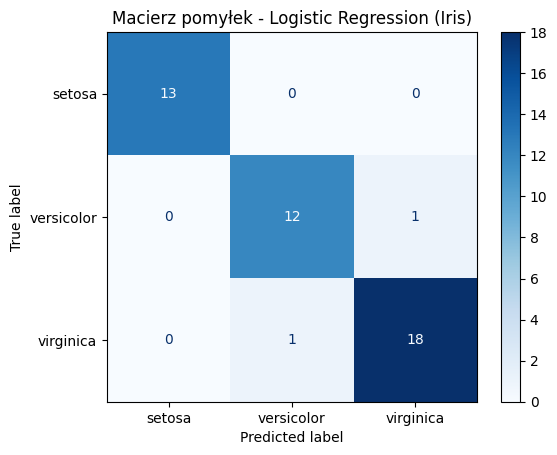

In [ ]:
# Ocena jakości
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nDokładność modelu: {acc:.2f}")

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Macierz pomyłek - Logistic Regression (Iris)")
plt.show()

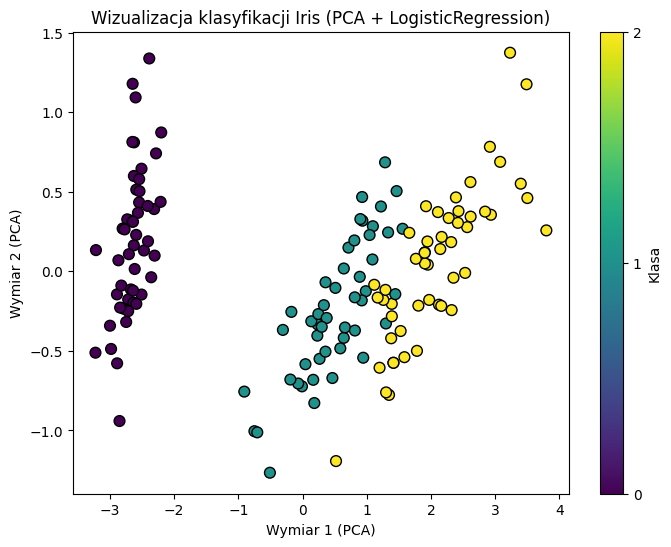

In [ ]:
# Wizualizacja (PCA)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
y_pred_all = model.predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_pred_all, cmap='viridis', s=60, edgecolor='k')
plt.title("Wizualizacja klasyfikacji Iris (PCA + LogisticRegression)")
plt.xlabel("Wymiar 1 (PCA)")
plt.ylabel("Wymiar 2 (PCA)")
plt.colorbar(ticks=[0,1,2], label='Klasa')
plt.show()